In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
df.isnull().sum()

df.drop_duplicates(inplace=True)

df['date'] = pd.to_datetime(df['date'], format = 'mixed', utc = True)

## Missing Value Handling

- Checked dataset for missing values using `isnull().sum()`
- Duplicate rows were removed
- Date column converted to datetime format
- Rows with critical missing values were dropped when necessary

In [5]:
df['headline_length'] = df['headline'].apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

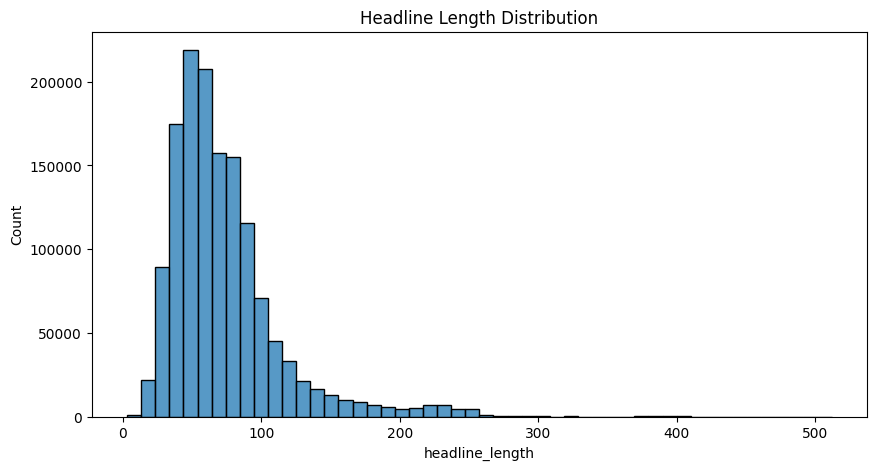

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=50)
plt.title("Headline Length Distribution")
plt.show()

In [7]:
top_publishers = df['publisher'].value_counts().head(10)

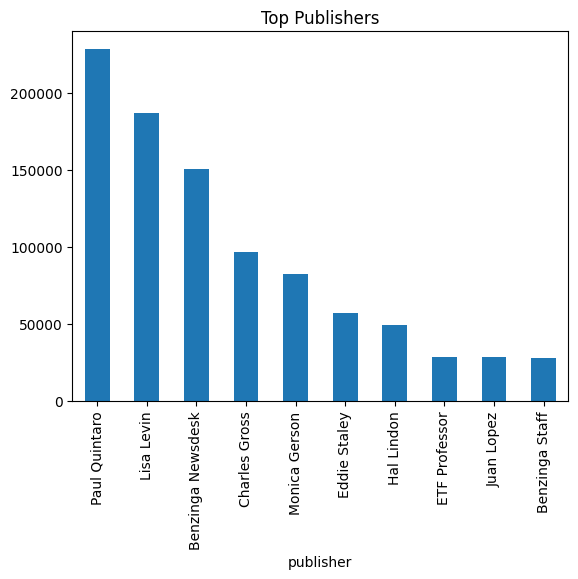

In [8]:
top_publishers.plot(kind='bar')
plt.title("Top Publishers")
plt.show()

In [9]:
daily_counts = df.groupby(df['date'].dt.date).size()

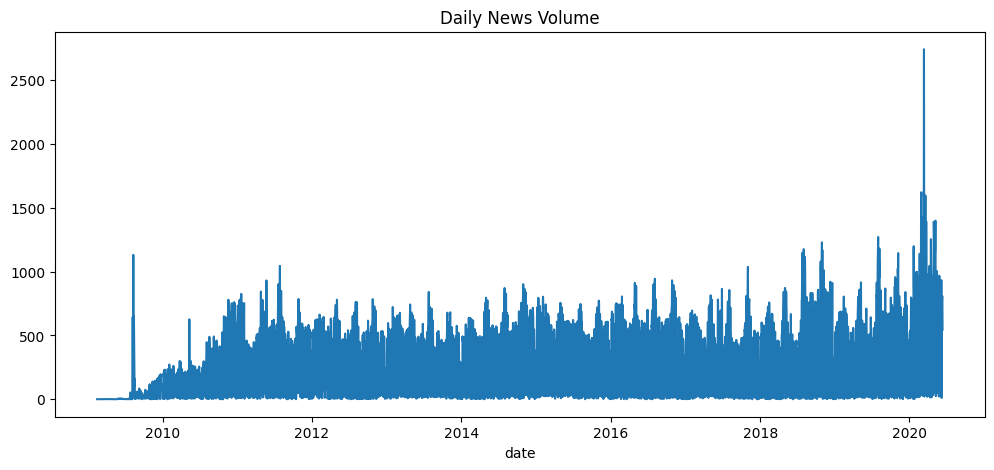

In [10]:
daily_counts.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()

In [11]:
df['hour'] = df['date'].dt.hour

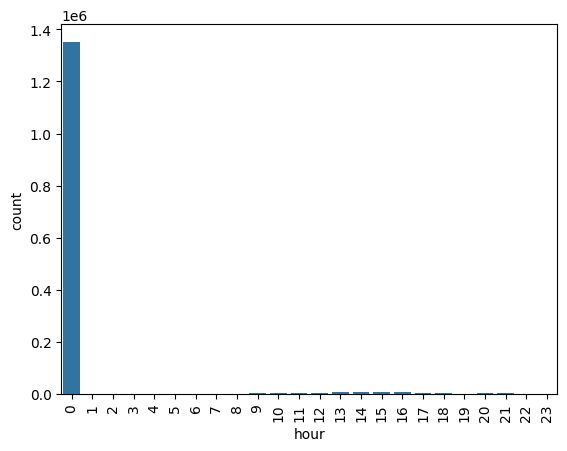

In [12]:
sns.countplot(x='hour', data=df)
plt.xticks(rotation=90)
plt.show()

In [13]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['headline'])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

word_freq = pd.DataFrame({
    'word': words,
    'count': counts
}).sort_values(by='count', ascending=False)

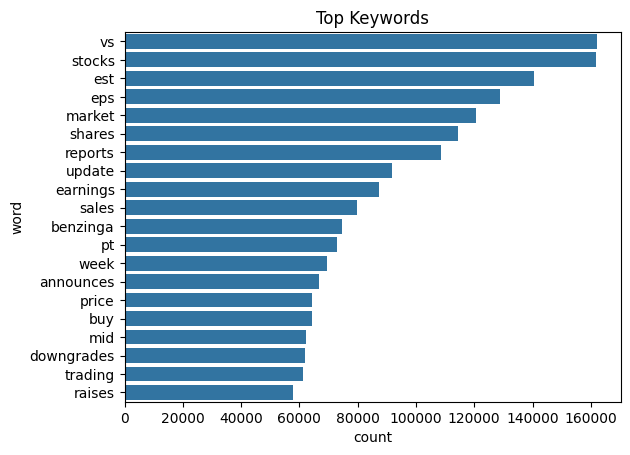

In [14]:
sns.barplot(data=word_freq, x='count', y='word')
plt.title("Top Keywords")
plt.show()